# Loading dataset

In [1]:
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
!pip install foundry_ml
!pip freeze

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.0/418.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 21.2 MB/s eta 0:00:00
absl-py==1.4.0
accelerate==1.15.0
access==1.1.10.post3
affine==3.0.1
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.1
altair==5.5.0
annotated-doc==0.0.5
annotated-types==0.8.0
antlr4-python3-runtime==4.9.3
anyio==4.15.1
anywidget==0.9.21
apsw==3.53.4.0
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.9.14.0.56.43
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioop-lts==0.2.2
audioread==3.1.0
Authlib==1.8.0
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.49.0
bigquery-magics==0.14

In [4]:
try:
  import google.colab
  no_local_server=True
  no_browser=True
  globus=False

  from google.colab import data_table
  data_table.enable_dataframe_formatter()
except: # when not in google colab
  no_local_server=False
  no_browser=False
  globus=True

In [5]:
from foundry import Foundry
f = Foundry(index="mdf", no_local_server=no_local_server, no_browser=no_browser, globus=globus)

doi = '10.18126/e73h-3w6n'
dataset = f.get_dataset(doi)
dataset

Please paste the following URL in a browser:
https://auth.globus.org/v2/oauth2/authorize?client_id=984464e2-90ab-433d-8145-ac0215d26c8e&redirect_uri=https%3A%2F%2Fauth.globus.org%2Fv2%2Fweb%2Fauth-code&scope=urn%3Aglobus%3Aauth%3Ascope%3Adata.materialsdatafacility.org%3Aall+https%3A%2F%2Fauth.globus.org%2Fscopes%2F4d5f8e8b-a61d-40d8-bb58-5a3f5d1d200a%2Fconnect+urn%3Aglobus%3Aauth%3Ascope%3Asearch.api.globus.org%3Asearch+https%3A%2F%2Fauth.globus.org%2Fscopes%2F56ceac29-e98a-440a-a594-b41e7a084b62%2Fall+urn%3Aglobus%3Aauth%3Ascope%3Atransfer.api.globus.org%3Aall+openid+https%3A%2F%2Fauth.globus.org%2Fscopes%2Ffacd7ccc-c5f4-42aa-916b-a0e270e2c2a9%2Fall+https%3A%2F%2Fauth.globus.org%2Fscopes%2Ff10a69a9-338c-4e5b-baa1-0dc92359ab47%2Fhttps+https%3A%2F%2Fauth.globus.org%2Fscopes%2F82f1b5c6-6e9b-11e5-ba47-22000b92c6ec%2Fhttps+https%3A%2F%2Fauth.globus.org%2Fscopes%2Fd31d4f5d-be37-4adc-a761-2f716b7af105%2Faction_all&state=_default&response_type=code&code_challenge=0doLRRNYPvYb7kgWt51lW2q_dc5i6

In [7]:
data = dataset.get_as_dict()
imgs = data['train']['input']['imgs']
info = data['train']['input']['metadata']
coords = data['train']['target']['coords']

# Inspecting metadata

In [13]:
import h5py

file_path = "/content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom.h5"

with h5py.File(file_path, "r") as f:
    print("Top-level keys:")
    for key in f.keys():
        print(" -", key)

    print("\nFull HDF5 structure:")

    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"{name}: Dataset "
                f"shape={obj.shape}, dtype={obj.dtype}"
            )
        else:
            print(f"{name}: Group")

    f.visititems(print_structure)

Top-level keys:
 - coords
 - imgs
 - metadata
 - raw

Full HDF5 structure:
coords: Group
coords/0000: Dataset shape=(647, 2), dtype=float64
coords/0001: Dataset shape=(647, 2), dtype=float64
coords/0002: Dataset shape=(647, 2), dtype=float64
coords/0003: Dataset shape=(647, 2), dtype=float64
coords/0004: Dataset shape=(647, 2), dtype=float64
coords/0005: Dataset shape=(647, 2), dtype=float64
coords/0006: Dataset shape=(647, 2), dtype=float64
coords/0007: Dataset shape=(647, 2), dtype=float64
coords/0008: Dataset shape=(647, 2), dtype=float64
coords/0009: Dataset shape=(647, 2), dtype=float64
coords/0010: Dataset shape=(364, 2), dtype=float64
coords/0011: Dataset shape=(365, 2), dtype=float64
coords/0012: Dataset shape=(367, 2), dtype=float64
coords/0013: Dataset shape=(362, 2), dtype=float64
coords/0014: Dataset shape=(362, 2), dtype=float64
coords/0015: Dataset shape=(365, 2), dtype=float64
coords/0016: Dataset shape=(364, 2), dtype=float64
coords/0017: Dataset shape=(362, 2), dtype=f

In [14]:
import pandas as pd

with pd.HDFStore(file_path, mode="r") as store:
    print(store.keys())

['/metadata']


In [15]:
metadata = pd.read_hdf(file_path, key="metadata")

print(metadata.shape)
print(metadata.columns)
print(metadata.head())

(299, 14)
Index(['key', 'Atoms/px', 'Material_orientation', 'Spacegroup', 'Type',
       'contrast', 'dose_e-/Å²', 'peakintensity_e-', 'pixelsize_pm',
       'probe_current_pA', 'resolution_pm', 'flybackerror', 'poisson_dB',
       'randomdrift'],
      dtype='object')
    key  Atoms/px Material_orientation  Spacegroup          Type  contrast  \
0  0000   5.65233          SrTiO3[001]  Pm-3m[221]  experimental     0.062   
1  0001   5.65233          SrTiO3[001]  Pm-3m[221]  experimental     0.048   
2  0002   5.65233          SrTiO3[001]  Pm-3m[221]  experimental     0.034   
3  0003   5.65233          SrTiO3[001]  Pm-3m[221]  experimental     0.088   
4  0004   5.65233          SrTiO3[001]  Pm-3m[221]  experimental     0.116   

   dose_e-/Å²  peakintensity_e-  pixelsize_pm  probe_current_pA  \
0    112237.0        528.408969         15.77             22.33   
1    112237.0        652.589082         15.77             22.33   
2    112237.0        856.422231         15.77             22

In [16]:
print(metadata.info())

for col in metadata.columns:
    print("\n", "="*60)
    print("COLUMN:", col)
    print("dtype:", metadata[col].dtype)
    print("unique values:", metadata[col].nunique(dropna=False))
    print(metadata[col].head(10).to_list())

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 298
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   299 non-null    object 
 1   Atoms/px              254 non-null    float64
 2   Material_orientation  299 non-null    object 
 3   Spacegroup            299 non-null    object 
 4   Type                  299 non-null    object 
 5   contrast              299 non-null    float64
 6   dose_e-/Å²            299 non-null    float64
 7   peakintensity_e-      299 non-null    float64
 8   pixelsize_pm          299 non-null    float64
 9   probe_current_pA      299 non-null    float64
 10  resolution_pm         254 non-null    float64
 11  flybackerror          185 non-null    float64
 12  poisson_dB            185 non-null    float64
 13  randomdrift           185 non-null    float64
dtypes: float64(10), object(4)
memory usage: 35.0+ KB
None

COLUMN: key
dtype: objec

## Find all experimental images

In [22]:
experimental_indices = metadata.index[
    metadata["Type"].astype(str).str.lower() == "experimental"
].tolist()

print("Number of experimental images:", len(experimental_indices))
print("Experimental image indices:")
print(experimental_indices)

Number of experimental images: 104
Experimental image indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 123, 124, 125, 126, 127, 128, 129, 130, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298]


In [23]:
experimental_df = metadata.loc[experimental_indices].copy()

display(experimental_df)

,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
0,0000,5.65233,SrTiO3[001],Pm-3m[221],experimental,0.062,1.122370e+05,528.408969,15.77,22.33,105.0,NaN,NaN,NaN
1,0001,5.65233,SrTiO3[001],Pm-3m[221],experimental,0.048,1.122370e+05,652.589082,15.77,22.33,105.0,NaN,NaN,NaN
2,0002,5.65233,SrTiO3[001],Pm-3m[221],experimental,0.034,1.122370e+05,856.422231,15.77,22.33,105.0,NaN,NaN,NaN
3,0003,5.65233,SrTiO3[001],Pm-3m[221],experimental,0.088,1.122370e+05,392.853173,15.77,22.33,105.0,NaN,NaN,NaN
4,0004,5.65233,SrTiO3[001],Pm-3m[221],experimental,0.116,1.122370e+05,320.827250,15.77,22.33,105.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,0294,NaN,WS2_1L[0001],P6-3/mmc[194],experimental,0.599,3.795053e+05,2968.000000,7.89,18.90,NaN,NaN,NaN,NaN
295,0295,NaN,WS2_1L[0001],P6-3/mmc[194],experimental,0.601,1.988469e+05,2917.000000,10.90,18.90,NaN,NaN,NaN,NaN
296,0296,NaN,WS2_1L[0001],P6-3/mmc[194],experimental,0.603,9.961629e+04,4941.000000,15.40,18.90,NaN,NaN,NaN,NaN
297,0297,NaN,WS2_1L[0001],P6-3/mmc[194],experimental,0.599,1.636080e+06,3137.000000,3.80,18.90,NaN,NaN,NaN,NaN


## Find all images of WS2[0001]

In [44]:
experimental_indices_WS2 = metadata.index[
    (metadata["Type"].astype(str).str.lower() == "experimental") &
    (metadata["Material_orientation"].astype(str).str.lower() == "ws2[0001]")
].tolist()

print("Number of experimental images:", len(experimental_indices_WS2))
print("Experimental image indices:")
print(experimental_indices_WS2)

Number of experimental images: 22
Experimental image indices:
[123, 124, 125, 126, 127, 128, 129, 130, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154]


In [45]:
experimental_df_WS2 = metadata.loc[experimental_indices].copy()

display(experimental_df_WS2)

,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
123,0123,8.393051,WS2[0001],P63/mmc[194],experimental,0.159,116783.034798,2502.422276,15.460,22.33,98.0,NaN,NaN,NaN
124,0124,8.393051,WS2[0001],P63/mmc[194],experimental,0.133,116783.034798,2365.907658,15.460,22.33,98.0,NaN,NaN,NaN
125,0125,8.393051,WS2[0001],P63/mmc[194],experimental,0.101,116783.034798,2229.216597,15.460,22.33,98.0,NaN,NaN,NaN
126,0126,8.393051,WS2[0001],P63/mmc[194],experimental,0.060,116783.034798,3164.079849,15.460,22.33,98.0,NaN,NaN,NaN
127,0127,8.393051,WS2[0001],P63/mmc[194],experimental,0.048,116783.034798,4146.385107,15.460,22.33,98.0,NaN,NaN,NaN
128,0128,8.393051,WS2[0001],P63/mmc[194],experimental,0.037,116783.034798,4616.112008,15.460,22.33,98.0,NaN,NaN,NaN
129,0129,8.393051,WS2[0001],P63/mmc[194],experimental,0.109,116783.034798,2270.713104,15.460,22.33,98.0,NaN,NaN,NaN
130,0130,8.393051,WS2[0001],P63/mmc[194],experimental,0.087,116783.034798,2179.196693,15.460,22.33,98.0,NaN,NaN,NaN
141,0141,4.282845,WS2[0001],P63/mmc[194],experimental,0.780,448492.127290,9112.000000,7.889,22.33,98.0,NaN,NaN,NaN
142,0142,2.953312,WS2[0001],P63/mmc[194],experimental,0.773,943193.798659,9830.000000,5.440,22.33,98.0,NaN,NaN,NaN


# Processing

Index: 141


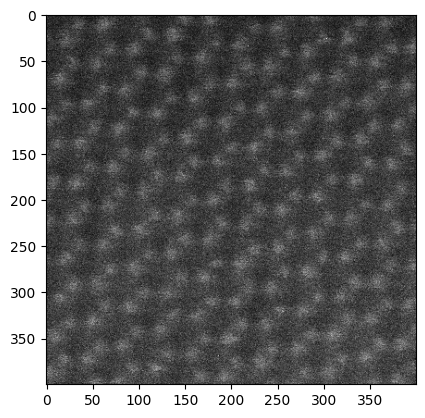

Index: 142


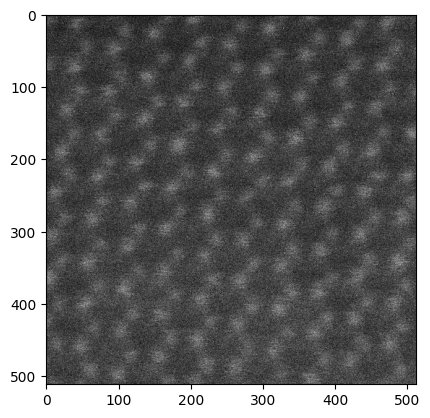

Index: 143


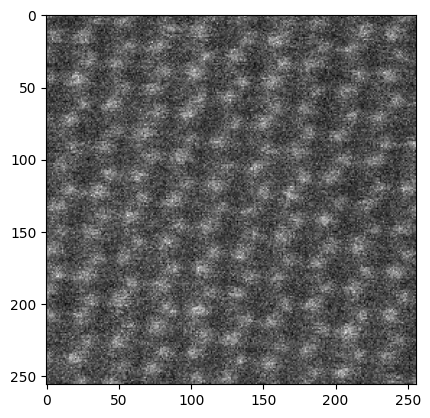

Index: 144


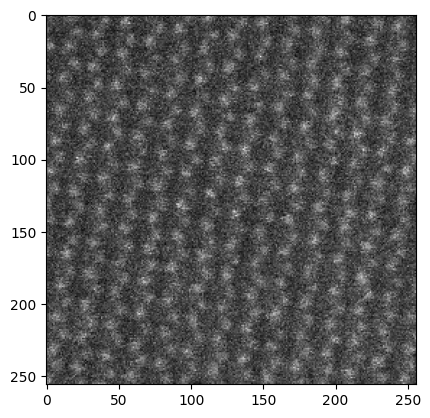

Index: 145


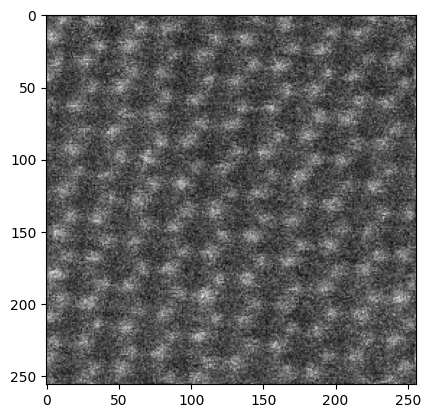

Index: 146


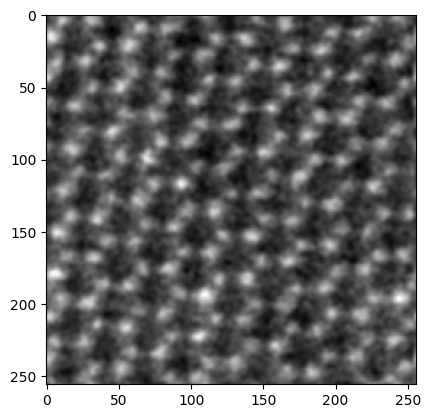

Index: 147


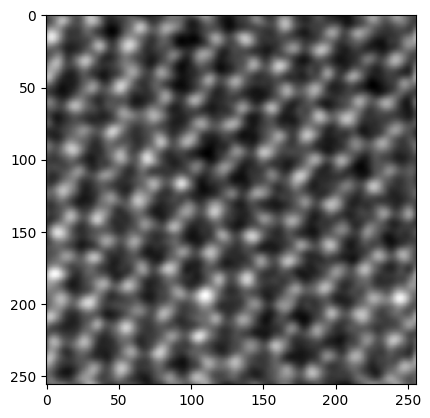

Index: 148


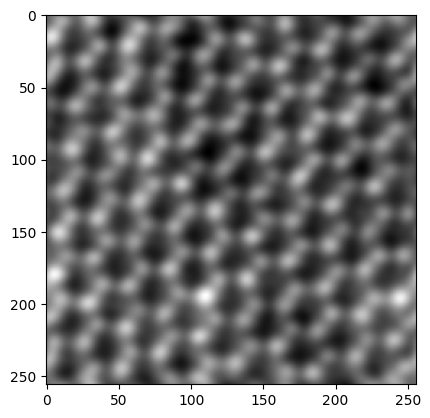

Index: 149


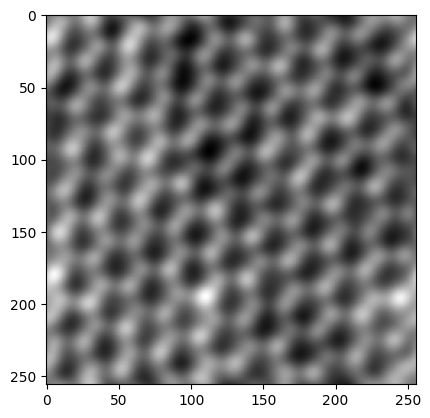

Index: 150


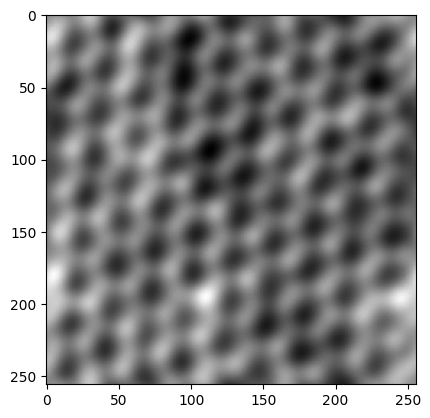

Index: 151


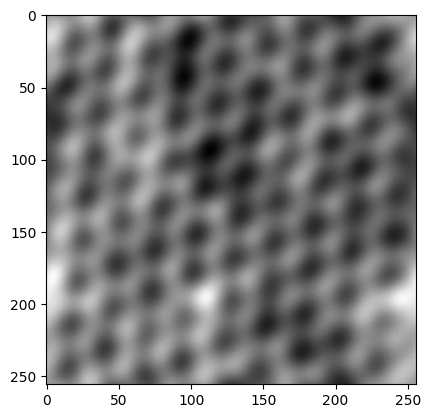

Index: 152


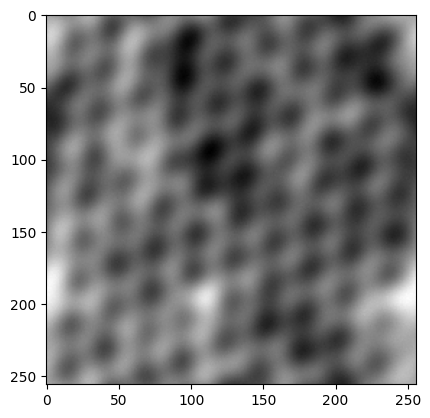

Index: 153


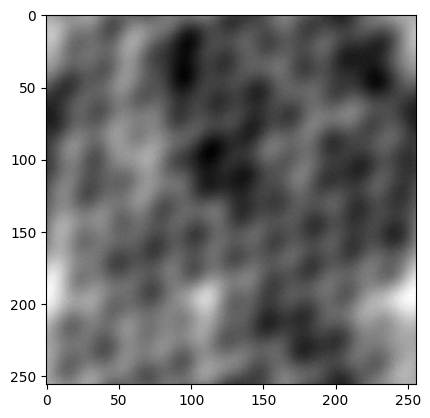

Index: 154


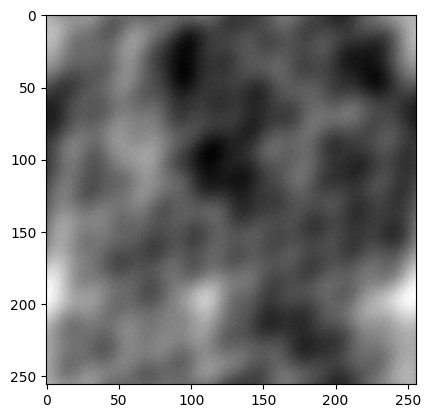

In [46]:
for index in range(141, 155):
  print(f"Index: {index}")
  key = list(imgs.keys())[index]
  im = np.asarray(imgs[key])
  plt.imshow(im, cmap = 'gray')
  plt.show()

# Creating subset dataset: contrast variation

In [49]:
input_file = "/content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom.h5"
output_file = "/content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom_subset_WS2_contrast_variation.h5"

# Example: choose any subset of image indices you want
selected_indices = [
    123, 124, 125, 126, 127,
    128, 129, 130
]

metadata = pd.read_hdf(input_file, key="metadata")

metadata_subset = metadata.loc[selected_indices].copy()

with h5py.File(input_file, "r") as src, h5py.File(output_file, "w") as dst:

    for group_name in ["imgs", "raw", "coords"]:
        src_group = src[group_name]
        dst_group = dst.create_group(group_name)

        for idx in selected_indices:
            key = f"{idx:04d}"

            if key not in src_group:
                raise KeyError(
                    f"{group_name}/{key} not found in source file."
                )

            src.copy(
                src_group[key],
                dst_group,
                name=key
            )

metadata_subset.to_hdf(
    output_file,
    key="metadata",
    mode="a",
    format="table"
)

print("Subset saved to:", output_file)
print("Number of images:", len(selected_indices))
print("Selected indices:", selected_indices)

Subset saved to: /content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom_subset_WS2_contrast_variation.h5
Number of images: 8
Selected indices: [123, 124, 125, 126, 127, 128, 129, 130]


In [50]:
with h5py.File(output_file, "r") as f:
    print("Top-level keys:", list(f.keys()))

    print("\nimgs:")
    print(list(f["imgs"].keys()))

    print("\nraw:")
    print(list(f["raw"].keys()))

    print("\ncoords:")
    print(list(f["coords"].keys()))

metadata_check = pd.read_hdf(output_file, key="metadata")

print("\nMetadata:")
display(metadata_check)

Top-level keys: ['coords', 'imgs', 'metadata', 'raw']

imgs:
['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

raw:
['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

coords:
['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

Metadata:


,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
123,0123,8.393051,WS2[0001],P63/mmc[194],experimental,0.159,116783.034798,2502.422276,15.46,22.33,98.0,NaN,NaN,NaN
124,0124,8.393051,WS2[0001],P63/mmc[194],experimental,0.133,116783.034798,2365.907658,15.46,22.33,98.0,NaN,NaN,NaN
125,0125,8.393051,WS2[0001],P63/mmc[194],experimental,0.101,116783.034798,2229.216597,15.46,22.33,98.0,NaN,NaN,NaN
126,0126,8.393051,WS2[0001],P63/mmc[194],experimental,0.060,116783.034798,3164.079849,15.46,22.33,98.0,NaN,NaN,NaN
127,0127,8.393051,WS2[0001],P63/mmc[194],experimental,0.048,116783.034798,4146.385107,15.46,22.33,98.0,NaN,NaN,NaN
128,0128,8.393051,WS2[0001],P63/mmc[194],experimental,0.037,116783.034798,4616.112008,15.46,22.33,98.0,NaN,NaN,NaN
129,0129,8.393051,WS2[0001],P63/mmc[194],experimental,0.109,116783.034798,2270.713104,15.46,22.33,98.0,NaN,NaN,NaN
130,0130,8.393051,WS2[0001],P63/mmc[194],experimental,0.087,116783.034798,2179.196693,15.46,22.33,98.0,NaN,NaN,NaN


In [51]:
with h5py.File(output_file, "r") as f:

    img_keys = set(f["imgs"].keys())
    raw_keys = set(f["raw"].keys())
    coord_keys = set(f["coords"].keys())

metadata_check = pd.read_hdf(output_file, key="metadata")

metadata_keys = {
    f"{idx:04d}"
    for idx in metadata_check.index
}

print("imgs == raw:   ", img_keys == raw_keys)
print("imgs == coords:", img_keys == coord_keys)
print("imgs == metadata:", img_keys == metadata_keys)

imgs == raw:    True
imgs == coords: True
imgs == metadata: True


# Creating subset dataset: dose variation

In [53]:
input_file = "/content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom.h5"
output_file = "/content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom_subset_WS2_dose_variation.h5"

# Example: choose any subset of image indices you want
selected_indices = [
    141, 142, 143, 145
]

metadata = pd.read_hdf(input_file, key="metadata")

metadata_subset = metadata.loc[selected_indices].copy()

with h5py.File(input_file, "r") as src, h5py.File(output_file, "w") as dst:

    for group_name in ["imgs", "raw", "coords"]:
        src_group = src[group_name]
        dst_group = dst.create_group(group_name)

        for idx in selected_indices:
            key = f"{idx:04d}"

            if key not in src_group:
                raise KeyError(
                    f"{group_name}/{key} not found in source file."
                )

            src.copy(
                src_group[key],
                dst_group,
                name=key
            )

metadata_subset.to_hdf(
    output_file,
    key="metadata",
    mode="a",
    format="table"
)

print("Subset saved to:", output_file)
print("Number of images:", len(selected_indices))
print("Selected indices:", selected_indices)

Subset saved to: /content/data/foundry_wei_atom_locating_benchmark_v1.1/wei_atom_subset_WS2_dose_variation.h5
Number of images: 4
Selected indices: [141, 142, 143, 145]


In [56]:
with h5py.File(output_file, "r") as f:
    print("Top-level keys:", list(f.keys()))

    print("\nimgs:")
    print(list(f["imgs"].keys()))

    print("\nraw:")
    print(list(f["raw"].keys()))

    print("\ncoords:")
    print(list(f["coords"].keys()))

metadata_check = pd.read_hdf(output_file, key="metadata")

print("\nMetadata:")
display(metadata_check)

Top-level keys: ['coords', 'imgs', 'metadata', 'raw']

imgs:
['0141', '0142', '0143', '0145']

raw:
['0141', '0142', '0143', '0145']

coords:
['0141', '0142', '0143', '0145']

Metadata:


,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
141,0141,4.282845,WS2[0001],P63/mmc[194],experimental,0.780,448492.127290,9112.0,7.889,22.33,98.0,NaN,NaN,NaN
142,0142,2.953312,WS2[0001],P63/mmc[194],experimental,0.773,943193.798659,9830.0,5.440,22.33,98.0,NaN,NaN,NaN
143,0143,5.944625,WS2[0001],P63/mmc[194],experimental,0.691,232793.311232,7692.0,10.950,22.33,98.0,NaN,NaN,NaN
145,0145,5.944625,WS2[0001],P63/mmc[194],experimental,0.715,232793.000000,7667.0,10.950,22.33,93.5,NaN,NaN,NaN


In [55]:
with h5py.File(output_file, "r") as f:

    img_keys = set(f["imgs"].keys())
    raw_keys = set(f["raw"].keys())
    coord_keys = set(f["coords"].keys())

metadata_check = pd.read_hdf(output_file, key="metadata")

metadata_keys = {
    f"{idx:04d}"
    for idx in metadata_check.index
}

print("imgs == raw:   ", img_keys == raw_keys)
print("imgs == coords:", img_keys == coord_keys)
print("imgs == metadata:", img_keys == metadata_keys)

imgs == raw:    True
imgs == coords: True
imgs == metadata: True


Image: 0143
Image shape: (256, 256)
Number of coordinates: 149


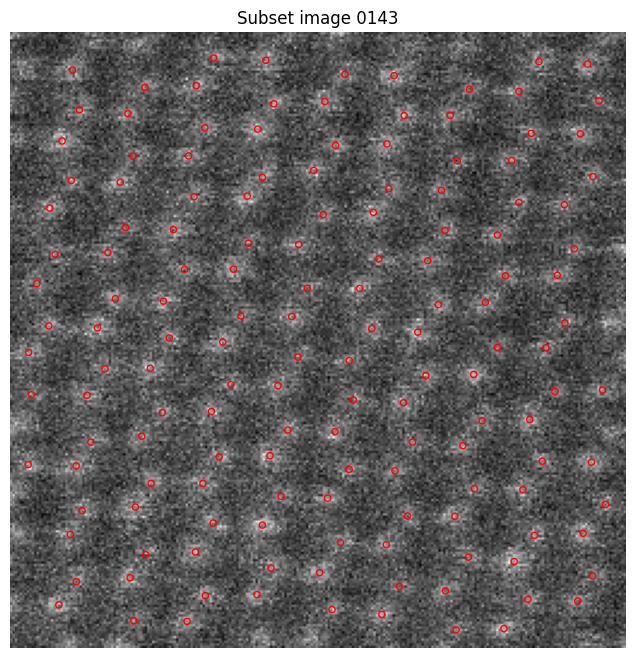

In [58]:
import h5py
import matplotlib.pyplot as plt

subset_file = output_file

with h5py.File(subset_file, "r") as f:
    image_keys = sorted(f["imgs"].keys())

    # take the first image in the subset
    key = image_keys[2]

    img = f["imgs"][key][:]
    coords = f["coords"][key][:]

print("Image:", key)
print("Image shape:", img.shape)
print("Number of coordinates:", len(coords))

plt.figure(figsize=(8, 8))

plt.imshow(img, cmap="gray")

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=20,
    facecolors="none",
    edgecolors="red",
    linewidths=1
)

plt.title(f"Subset image {key}")
plt.axis("off")
plt.show()